<a href="https://colab.research.google.com/github/vinothkumard2006-ai/Practice-in-colab/blob/main/AI%20vs%20Human%20text%20classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Untitled spreadsheet.gsheet',
 'job survey.gsheet',
 'final_combined_enriched_v4.csv',
 'Colab Notebooks',
 'Medicinal plant dataset',
 'data_for_preprocessing.csv']

In [3]:
import pandas as pd

df_preprocessing = pd.read_csv('/content/drive/MyDrive/data_for_preprocessing.csv')


In [4]:
df_preprocessing


,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human
...,...,...,...
6064,6064,Computational models serve as useful compleme...,Human
6065,6065,During transport and storage of drinking wate...,Human
6066,6066,The parameter values of neural networks will ...,Human
6067,6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human


In [5]:
df_preprocessing.shape

(6069, 3)

In [6]:
df_preprocessing.isna().sum()

,0
Unnamed: 0,0
Text,0
Author,0


In [7]:
df_preprocessing.dtypes

,0
Unnamed: 0,int64
Text,object
Author,object


In [10]:
if 'Unnamed: 0' in df_preprocessing.columns:
    df_preprocessing = df_preprocessing.drop(columns=['Unnamed: 0'])

In [12]:
display(df_preprocessing)

,Text,Author
0,This study investigates the chemical compositi...,AI
1,This study explores the cultural history of oi...,AI
2,Isolation of human peripheral blood mononucle...,Human
3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,"Within volleyball, performance analysis is em...",Human
...,...,...
6064,Computational models serve as useful compleme...,Human
6065,During transport and storage of drinking wate...,Human
6066,The parameter values of neural networks will ...,Human
6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human


In [15]:
print(df_preprocessing['Author'].unique())

['AI' 'Human']


In [19]:
display(df_preprocessing.describe(include='all'))

,Text,Author
count,6069,6069
unique,6069,2
top,Generative AI for video is computationally exp...,AI
freq,1,3069


/tmp/ipykernel_5783/4291352475.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Author', y='Count', data=author_counts, palette='viridis')


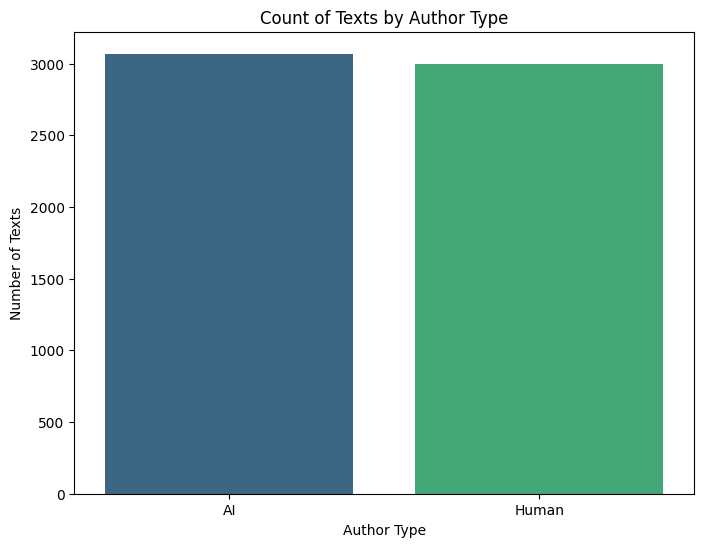

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the counts of each author type
author_counts = df_preprocessing['Author'].value_counts().reset_index()
author_counts.columns = ['Author', 'Count']

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Author', y='Count', data=author_counts, palette='viridis')
plt.title('Count of Texts by Author Type')
plt.xlabel('Author Type')
plt.ylabel('Number of Texts')
plt.show()

In [25]:
# Very Important (text Cleaning)

import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words=set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https\S+', '', text)   ## remove urls
    text = re.sub(r'@\w+', '', text)  ## remove mentions
    text = re.sub(r'#\w+', '', text)  ## remove hastags
    text = re.sub(r'[^a-z\s]', '', text)  ## remove punctuations

    text = " ".join([word for word in text.split() if word not in stop_words])

    return text

df_preprocessing['clean_Text']=df_preprocessing['Text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
from sklearn.model_selection import train_test_split

X=df_preprocessing['clean_Text']
y=df_preprocessing['Author']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)